# Exploratory Data Analysis
## Gym Members Exercise Dataset

Author: Sarah Suliman

Course: CSPB 4502 Data Mining

## Project Overview

This notebook explores the Gym Members Exercise Dataset as part of a data mining project focused on fitness behavior and workout performance. The goal of this exploratory analysis is to understand the dataset structure, check data quality, examine key variables, and identify early relationships that can guide later clustering, classification, and regression models.

The main project questions are:

1. Can gym members be grouped into meaningful fitness profiles?
2. Which factors are most strongly associated with calories burned?
3. Can a member's experience level be predicted from fitness and workout characteristics?

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [8]:
DATA_PATH = Path("../data/gym_members_exercise_tracking.csv")
FIGURES_DIR = Path("../figures")

FIGURES_DIR.mkdir(exist_ok=True)

## Load the Dataset

In [9]:
df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Dataset Overview

In [10]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 973
Columns: 15


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [12]:
df.columns.tolist()

['Age',
 'Gender',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Workout_Type',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI']

## Missing Values

Before modeling, I checked whether the dataset contains missing values. Missing values can affect summary statistics, visualizations, and machine learning models.

In [13]:
missing_values = df.isnull().sum()
missing_values

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

The dataset does not contain missing values, which makes it easier to begin exploratory analysis and modeling. Later preprocessing steps will still check for duplicates, unusual values, and variables that need encoding or scaling.

## Summary Statistics

In [14]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


The dataset includes several useful numerical variables, including age, weight, height, heart rate measurements, session duration, calories burned, fat percentage, water intake, workout frequency, experience level, and BMI. These variables are useful for correlation analysis, regression, clustering, and classification.

## Categorical Variables

In [15]:
df["Workout_Type"].value_counts()

Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64

In [16]:
df["Gender"].value_counts()

Gender
Male      511
Female    462
Name: count, dtype: int64

In [17]:
df["Experience_Level"].value_counts()

Experience_Level
2    406
1    376
3    191
Name: count, dtype: int64

The workout types are fairly balanced across strength, cardio, yoga, and HIIT. Gender is also relatively balanced. Experience level has three categories, with level 2 appearing most often, followed by level 1 and level 3. This gives the project enough variation to support classification and clustering analysis.

## Correlation Analysis

The next step is to examine how numerical variables relate to calories burned. This is useful because one research question asks which factors are most strongly associated with calorie expenditure.

In [18]:
calorie_correlations = (
    df.corr(numeric_only=True)["Calories_Burned"]
    .sort_values(ascending=False)
)

calorie_correlations

Calories_Burned                  1.000000
Session_Duration (hours)         0.908140
Experience_Level                 0.694129
Workout_Frequency (days/week)    0.576150
Water_Intake (liters)            0.356931
Avg_BPM                          0.339659
Weight (kg)                      0.095443
Height (m)                       0.086348
BMI                              0.059761
Resting_BPM                      0.016518
Max_BPM                          0.002090
Age                             -0.154679
Fat_Percentage                  -0.597615
Name: Calories_Burned, dtype: float64

The strongest positive relationship is between session duration and calories burned. This makes sense because longer workout sessions generally provide more time for energy expenditure. Experience level and workout frequency also show positive relationships with calories burned, suggesting that more experienced and more frequent gym members may burn more calories during sessions.

Body fat percentage shows a negative relationship with calories burned in this dataset. This does not prove causation, but it does suggest a meaningful pattern that may be worth examining further during modeling.

## Scatter Plot: Session Duration vs. Calories Burned

In [19]:
x_col = "Session_Duration (hours)"
y_col = "Calories_Burned"

correlation = df[x_col].corr(df[y_col])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.908


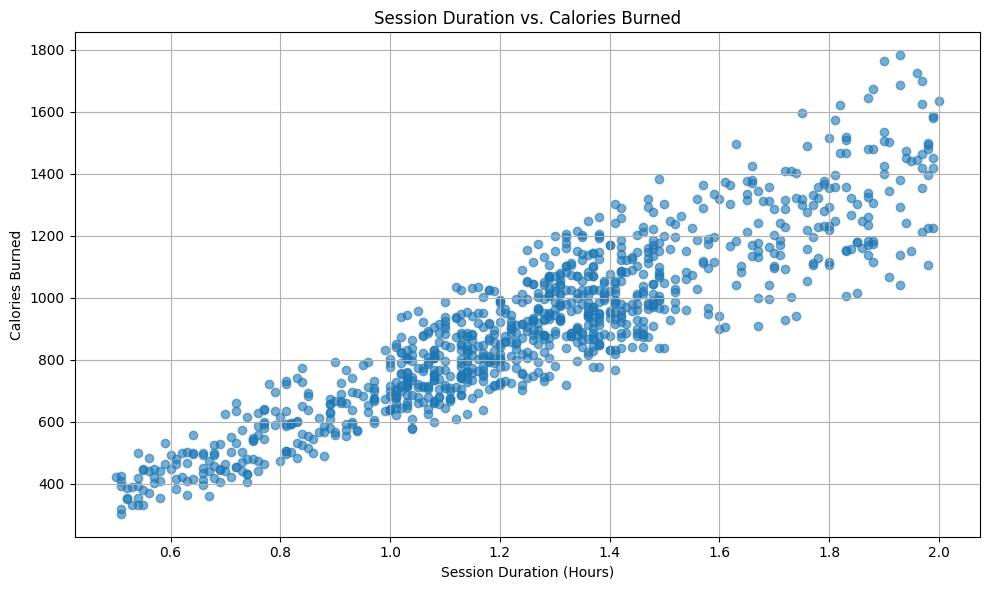

Figure saved to: ../figures/session_duration_vs_calories_burned.png


In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[x_col],
    df[y_col],
    alpha=0.6
)

plt.title("Session Duration vs. Calories Burned")
plt.xlabel("Session Duration (Hours)")
plt.ylabel("Calories Burned")
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "session_duration_vs_calories_burned.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

The scatter plot shows a clear positive relationship between session duration and calories burned. This supports the preliminary correlation result and suggests that session duration will likely be an important predictor in later regression models.

## Distribution of Calories Burned

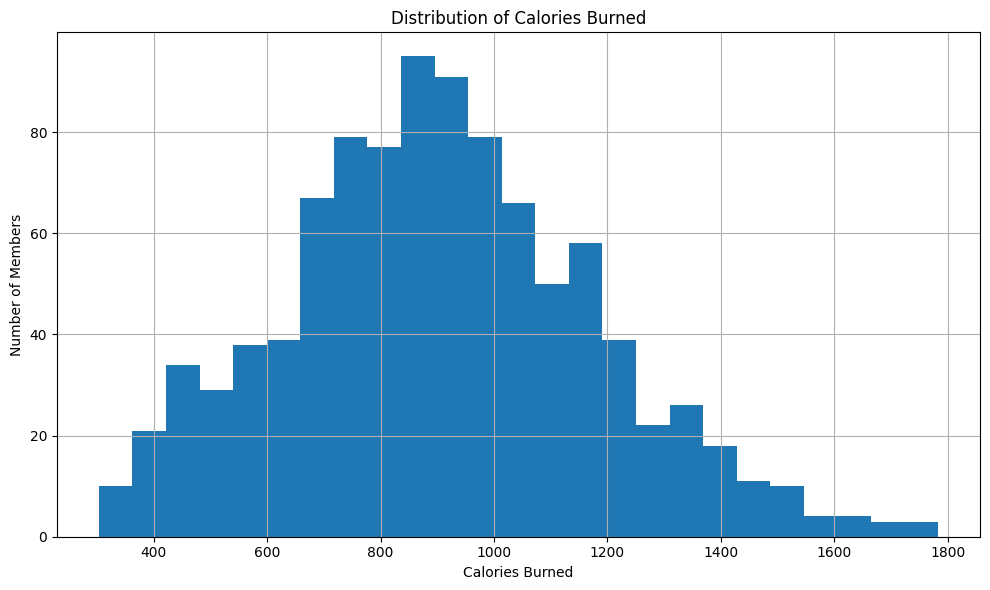

Figure saved to: ../figures/calories_burned_distribution.png


In [21]:
plt.figure(figsize=(10, 6))

plt.hist(df["Calories_Burned"], bins=25)

plt.title("Distribution of Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Number of Members")
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "calories_burned_distribution.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

This histogram helps show how calories burned are distributed across the dataset. Understanding this distribution is important before building regression models because extreme values or skewed distributions can affect model performance.

## Distribution of BMI

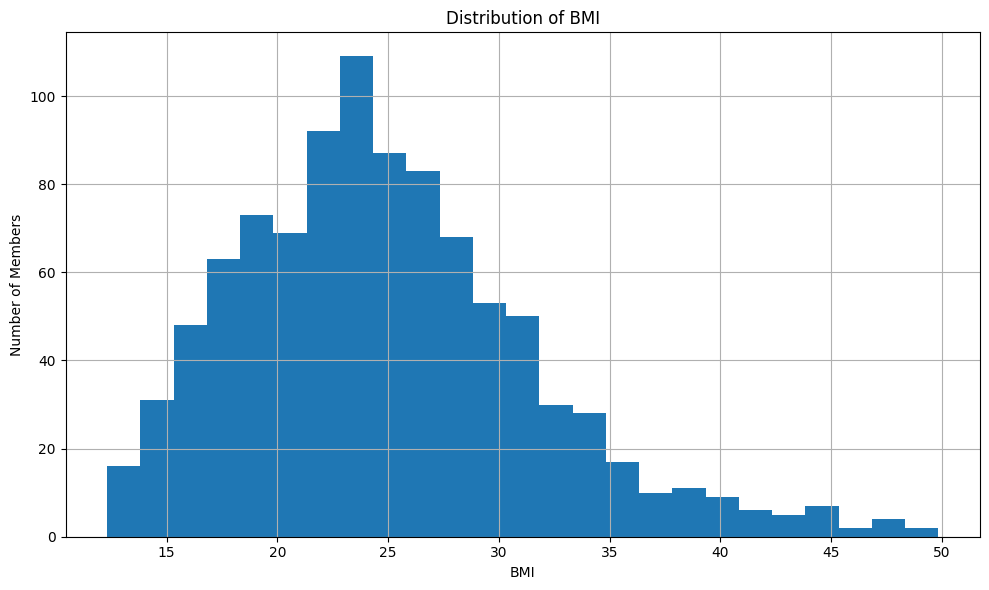

Figure saved to: ../figures/bmi_distribution.png


In [22]:
plt.figure(figsize=(10, 6))

plt.hist(df["BMI"], bins=25)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Members")
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "bmi_distribution.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

BMI is one of the physical characteristics that may help identify different fitness profiles. Later, BMI can be used as one of the clustering variables alongside body fat percentage, workout frequency, session duration, and calories burned.

## Workout Type Distribution

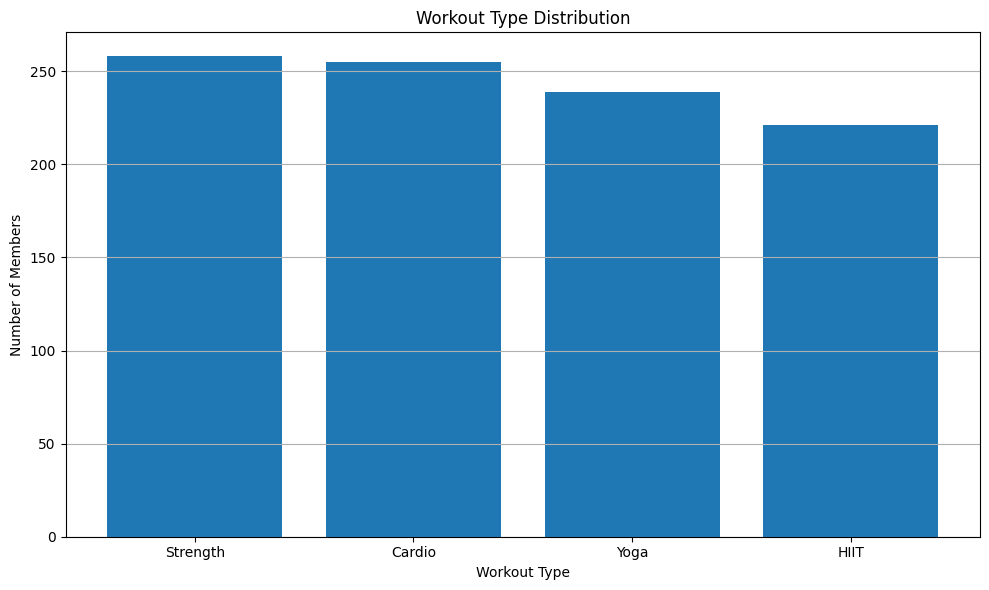

Figure saved to: ../figures/workout_type_distribution.png


In [23]:
workout_counts = df["Workout_Type"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(workout_counts.index, workout_counts.values)

plt.title("Workout Type Distribution")
plt.xlabel("Workout Type")
plt.ylabel("Number of Members")
plt.grid(axis="y")
plt.tight_layout()

output_path = FIGURES_DIR / "workout_type_distribution.png"
plt.savefig(output_path, dpi=300)

plt.show()

print(f"Figure saved to: {output_path}")

The workout type distribution shows that the dataset includes a mix of strength, cardio, yoga, and HIIT workouts. This variety is useful because workout type may influence calories burned, experience level, and fitness profile grouping.

## Initial Findings

This exploratory analysis produced several useful findings:

- The dataset contains 973 rows and 15 columns.
- No missing values were found.
- Workout type and gender are relatively balanced.
- Session duration has a strong positive correlation with calories burned.
- Experience level and workout frequency also show positive relationships with calories burned.
- Body fat percentage shows a moderate negative relationship with calories burned.

These findings suggest that the dataset is suitable for data mining tasks such as clustering, classification, and regression.

## Next Steps

The next phase of the project will focus on preprocessing. This will include encoding categorical variables, scaling numerical features, checking for duplicates and outliers, and preparing the dataset for machine learning models.

Planned modeling tasks include:

1. K-Means clustering to identify fitness profiles.
2. Classification models to predict experience level.
3. Regression models to predict calories burned.